# 第 8 章 · 降维

从零实现 `MyPCA` (协方差矩阵 + 特征值分解)，与 sklearn `PCA` 对比，最后用 t-SNE 可视化高维手写数字数据。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# 中文字体配置（仅在此cell设置一次，后续cell直接使用plt即可）
import os, platform
if platform.system() == 'Linux' and os.path.exists('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf'):
    fm.fontManager.addfont('/usr/share/fonts/truetype/chinese/NotoSansSC-Regular.ttf')
plt.rcParams['font.sans-serif'] = ['Noto Sans SC', 'DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 11

COLORS = {
    'primary': '#6b6144', 'accent': '#96781b', 'accent2': '#459ebb',
    'pos': '#c0392b', 'neg': '#2980b9', 'green': '#3d8e58', 'muted': '#88867f'
}

import pandas as pd
from sklearn.decomposition import PCA as SkPCA
from sklearn.manifold import TSNE
from sklearn.datasets import load_iris, load_digits
from sklearn.preprocessing import StandardScaler

PALETTE = [COLORS['accent'],COLORS['accent2'],COLORS['green'],COLORS['pos'],
           COLORS['primary'],COLORS['neg'],COLORS['muted'],'#555','#aaa','#714']


## 8.1 算法原理

PCA 寻找数据方差最大的方向：① 中心化 $X_c=X-\bar{X}$ ② 协方差矩阵 $\Sigma=\frac{1}{n}X_c^\top X_c$ ③ 特征值分解 $\Sigma=U\Lambda U^\top$ ④ 取前 $k$ 大特征值对应的特征向量作为投影矩阵 $W_k$ ⑤ $Z=X_c W_k$。

解释方差比 $\frac{\lambda_i}{\sum_j\lambda_j}$ 衡量每个主成分保留了多少信息。

> PDF 伪代码步骤：① 中心化 ② 协方差 ③ 特征值分解 ④ 排序 ⑤ 取前k；transform: 投影 $Z=(X-\mu)\cdot W_k^\top$。

## 8.2 从零实现 (核心)

代码注释中的步骤编号与 PDF 伪代码一一对应。

In [ ]:
class MyPCA:
    """从零实现的 PCA (协方差矩阵 + 特征值分解)。接口与 sklearn 一致。"""
    def __init__(self, n_components=2):
        self.n_components = n_components

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        # 步骤1: 中心化 μ = mean(X), X = X - μ
        self.mean_ = X.mean(axis=0)
        Xc = X - self.mean_
        # 步骤2: 协方差矩阵 C = (1/n)·XᵀX
        cov = np.cov(Xc, rowvar=False)
        # 步骤3: 特征值分解 Cv = λv
        eigvals, eigvecs = np.linalg.eigh(cov)
        # 步骤4: 按λ降序排列
        order = np.argsort(eigvals)[::-1]
        self.explained_variance_ = eigvals[order]
        total = self.explained_variance_.sum()
        self.explained_variance_ratio_ = self.explained_variance_ / total
        # 步骤5: 取前k个特征向量 components_
        self.components_ = eigvecs[:, order[:self.n_components]].T
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        Xc = X - self.mean_
        # 投影: Z = (X - μ) · components_ᵀ
        return Xc @ self.components_.T

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)


## 8.3 简单验证 + 与 sklearn 对比 (鸢尾花)

把 4 维鸢尾花降到 2 维，对比自定义与 sklearn 的投影与解释方差比。

自定义 解释方差比: [0.7296 0.2285]
sklearn 解释方差比: [0.7296 0.2285]


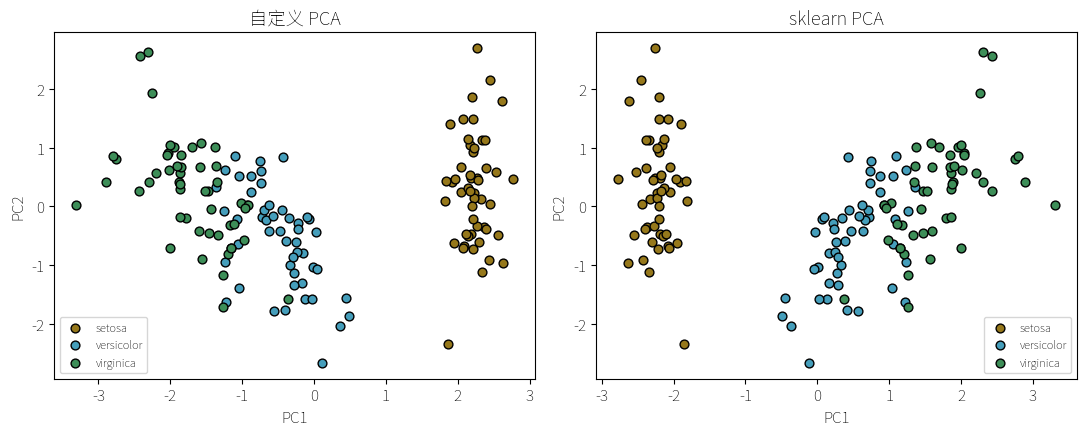

In [ ]:
iris = load_iris()
X = StandardScaler().fit_transform(iris.data)
y = iris.target

my_pca = MyPCA(n_components=2).fit(X)
sk_pca = SkPCA(n_components=2).fit(X)
Z_my = my_pca.transform(X)
Z_sk = sk_pca.transform(X)
print('自定义 解释方差比:', np.round(my_pca.explained_variance_ratio_[:2],4))
print('sklearn 解释方差比:', np.round(sk_pca.explained_variance_ratio_,4))

fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
for ax, (Z, t) in zip(axes, [(Z_my,'自定义 PCA'),(Z_sk,'sklearn PCA')]):
    for k in range(3):
        m=y==k
        ax.scatter(Z[m,0], Z[m,1], c=PALETTE[k], edgecolor='k', s=40, label=iris.target_names[k])
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title(t); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 8.4 累计解释方差 (手写数字)

64 维手写数字，画前若干主成分的累计方差比，决定保留多少维。

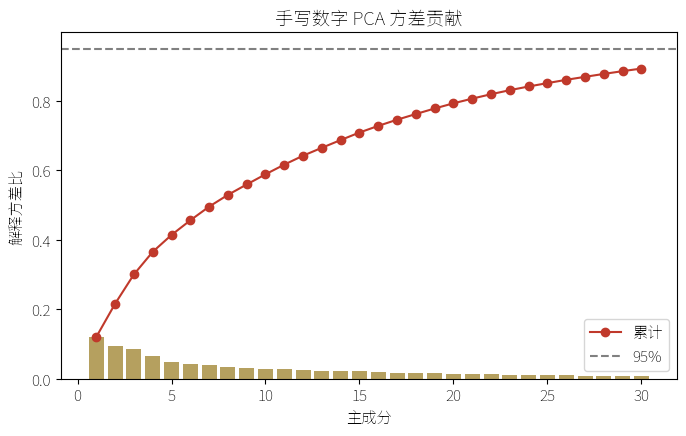

In [ ]:
digits = load_digits()
X = StandardScaler().fit_transform(digits.data)
my_pca = MyPCA(n_components=30).fit(X)
cum = np.cumsum(my_pca.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(range(1,31), my_pca.explained_variance_ratio_[:30], color=COLORS['accent'], alpha=0.7)
ax.plot(range(1,31), cum[:30], '-o', c=COLORS['pos'], label='累计')
ax.axhline(0.95, c='gray', ls='--', label='95%')
ax.set_xlabel('主成分'); ax.set_ylabel('解释方差比'); ax.legend()
ax.set_title('手写数字 PCA 方差贡献'); plt.tight_layout(); plt.show()


## 8.5 真实应用 · PCA + t-SNE 可视化

PCA 是线性降维，t-SNE 是非线性降维，更适合高维数据的 2D 可视化。对比 PCA(2D) 与 t-SNE(2D) 在手写数字上的聚类分离效果。

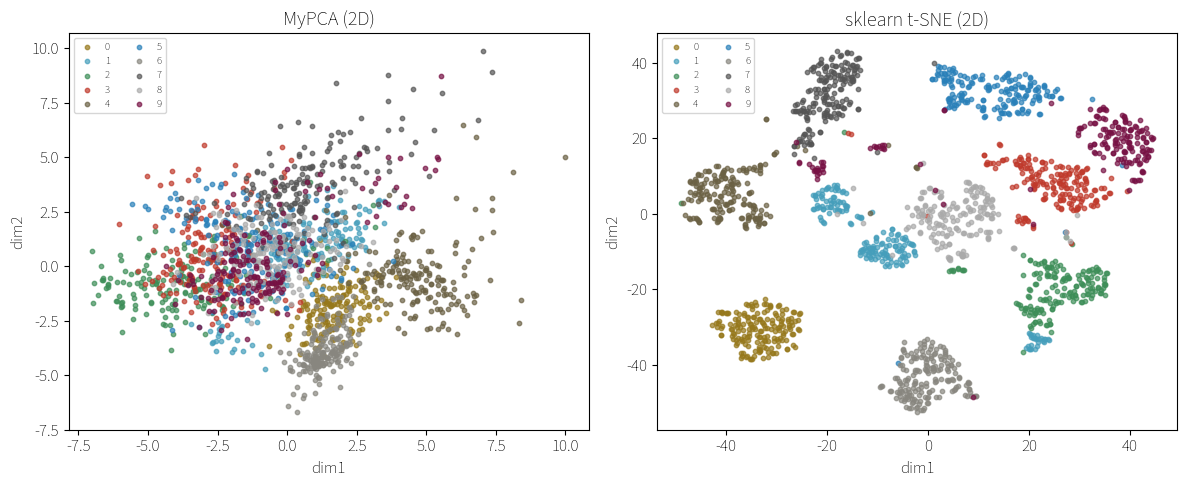

In [ ]:
X = StandardScaler().fit_transform(digits.data)
y = digits.target
Z_pca = MyPCA(n_components=2).fit_transform(X)
tsne = TSNE(n_components=2, init='pca', learning_rate='auto',
            random_state=42, perplexity=30)
Z_tsne = tsne.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(12,5))
for ax, (Z, t) in zip(axes, [(Z_pca,'MyPCA (2D)'),(Z_tsne,'sklearn t-SNE (2D)')]):
    for k in range(10):
        m=y==k
        ax.scatter(Z[m,0], Z[m,1], c=PALETTE[k], s=10, label=str(k), alpha=0.7)
    ax.set_xlabel('dim1'); ax.set_ylabel('dim2'); ax.set_title(t); ax.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()


## 8.6 真实应用 · PCA 压缩 + 重建

用前 k 个主成分重构图像，直观感受“信息量”被保留的程度。

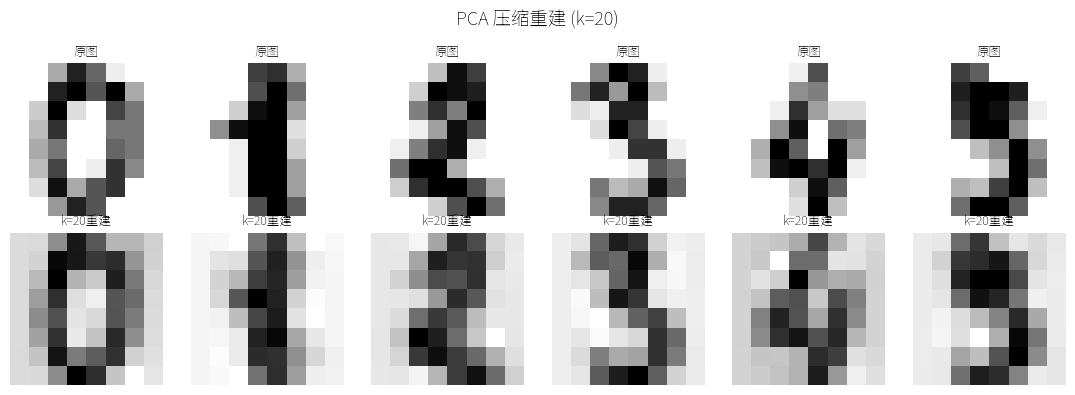

In [ ]:
X = digits.data.astype(float)
mean = X.mean(0)
Xc = X - mean
k = 20
pca = MyPCA(n_components=k).fit(X)
Z = pca.transform(X)
recon = Z @ pca.components_ + mean

fig, axes = plt.subplots(2, 6, figsize=(11,4))
for i in range(6):
    axes[0,i].imshow(X[i].reshape(8,8), cmap='gray_r'); axes[0,i].axis('off')
    axes[0,i].set_title('原图', fontsize=9)
    axes[1,i].imshow(recon[i].reshape(8,8), cmap='gray_r'); axes[1,i].axis('off')
    axes[1,i].set_title(f'k={k}重建', fontsize=9)
plt.suptitle(f'PCA 压缩重建 (k={k})'); plt.tight_layout(); plt.show()


## 8.7 小结

- PCA 通过协方差矩阵特征分解找到方差最大方向，与 sklearn 结果一致；
- 解释方差比帮助选择保留维数 (如 95% 累计)；
- t-SNE 擅长高维可视化但每次结果不同、不能用于新样本变换。